<a href="https://colab.research.google.com/github/saifmukadam10/Multi-Armed-Bandit-Problem/blob/main/MultiArmedBandit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
# ============================================
# Multi-Armed Bandit using Epsilon-Greedy
# Google Colab / Jupyter Notebook Version
# ============================================

# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [16]:
# -------------------------------
# Multi-Armed Bandit Environment
# -------------------------------
class MultiArmedBandit:
    def __init__(self, k, means, std_devs):
        self.k = k                      # Number of arms
        self.means = means              # Mean reward for each arm
        self.std_devs = std_devs        # Standard deviation for each arm

    def pull(self, arm):
        """
        Simulate pulling an arm and return a reward
        """
        return np.random.normal(self.means[arm], self.std_devs[arm])

In [17]:
# -----------------------------------
# Epsilon-Greedy Strategy
# -----------------------------------
class EpsilonGreedy:
    def __init__(self, epsilon, k):
        self.epsilon = epsilon
        self.k = k

        # Estimated reward values for each arm
        self.q_values = np.zeros(k)

        # Number of times each arm has been selected
        self.arm_counts = np.zeros(k)

    def select_arm(self):
        """
        Select an arm using epsilon-greedy policy
        """
        # Exploration
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.k)

        # Exploitation
        return np.argmax(self.q_values)

    def update(self, arm, reward):
        """
        Update estimated reward for selected arm
        """
        self.arm_counts[arm] += 1

        # Incremental mean update formula
        self.q_values[arm] += (
            reward - self.q_values[arm]
        ) / self.arm_counts[arm]



In [18]:
# -----------------------------------
# Simulation Function
# -----------------------------------
def simulate_bandit(bandit, strategy, n_steps):

    rewards = np.zeros(n_steps)

    for step in range(n_steps):

        # Select arm
        arm = strategy.select_arm()

        # Get reward from environment
        reward = bandit.pull(arm)

        # Update strategy
        strategy.update(arm, reward)

        # Store reward
        rewards[step] = reward

    return rewards

In [19]:
# -----------------------------------
# Plotting Function
# -----------------------------------
def plot_average_reward(epsilon_rewards_list, n_steps, epsilons):

    plt.figure(figsize=(12, 7))

    # Calculate cumulative average rewards
    avg_rewards_list = [
        np.cumsum(rewards) / (np.arange(1, n_steps + 1))
        for rewards in epsilon_rewards_list
    ]

    # Plot each epsilon result
    for avg_rewards, epsilon in zip(avg_rewards_list, epsilons):
        plt.plot(
            avg_rewards,
            label=f"Epsilon = {epsilon}"
        )

    plt.xlabel("Steps")
    plt.ylabel("Average Reward")
    plt.title("Epsilon-Greedy Multi-Armed Bandit")
    plt.legend()
    plt.grid(True)

    plt.show()

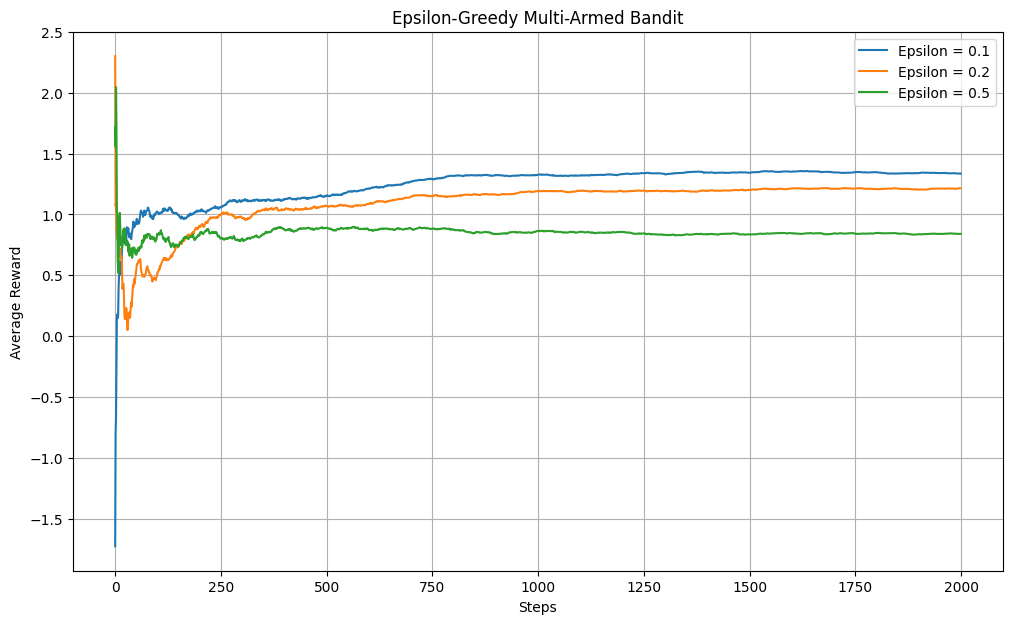

In [20]:
# ============================================
# Main Program
# ============================================

# Number of arms
k = 10

# Generate random mean rewards for each arm
means = np.random.normal(0, 1, k)

# Standard deviation for each arm
std_devs = np.ones(k)

# Create bandit environment
bandit = MultiArmedBandit(k, means, std_devs)

# Different epsilon values to compare
epsilons = [0.1, 0.2, 0.5]

# Number of simulation steps
n_steps = 2000

# Store rewards for each epsilon
epsilon_rewards_list = []

# Run simulations
for epsilon in epsilons:

    strategy = EpsilonGreedy(epsilon, k)

    rewards = simulate_bandit(
        bandit,
        strategy,
        n_steps
    )

    epsilon_rewards_list.append(rewards)

# Plot final graph
plot_average_reward(
    epsilon_rewards_list,
    n_steps,
    epsilons
)